In [1]:
import numpy as np              # load numerical module
import matplotlib.pyplot as plt # load plotting module
import astropy.io.fits as fits  # get FITS 
import pandas as pd             # get pandas 

import os                       #import os module

## Convolution

- Convolution of two functions (f,g) describes how the shape of one (g) is affected by the other as the former (f) shifts over the latter(g). In math, convolution is "the integral of the product of the two functions after one is reflected about the y-axis and shifted: $(f*g)(t) = \int f(\tau) g(t-\tau) d\tau $ "

- In astronomy it is used to describe signal spreading (among other things)

    - Divide signal into discrete points
    - Multiply each point by a function
    - Replace point with function, shifted to location of point
        - $$
(f*g)(t) \equiv \int_{-\infty}^{\infty}f(\tau)g(t-\tau){\rm d}\tau = \int_{-\infty}^{\infty}f(t-\tau)g(\tau){\rm d}\tau$$ 
        - $$
(f*g)(n) \equiv \sum_{m=-\infty}^{\infty}f(m)g(n-m) = \sum_{m=-\infty}^{\infty}f(n-m)g(m)
$$


In [2]:
#let's make our x array:
x      = np.arange( -30, 30, 0.2 )

m1 = 0
m2 = 10

#then make our simple window funct:
funct1 = np.zeros( len( x ) )
funct1[ (x >=m1 ) & (x<=m2 ) ] = 1

#make another window funct shifted by 90 pixels:
w = 0.8
funct2 = np.roll( funct1, -90 )*w 

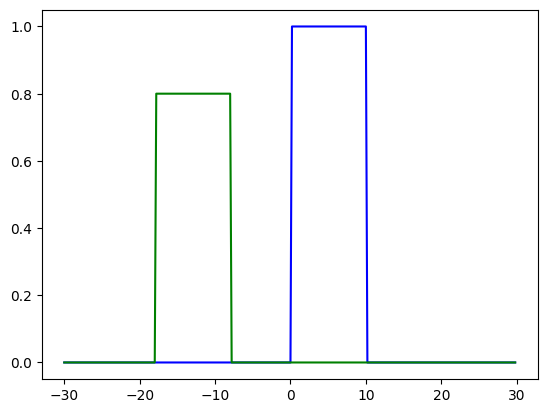

In [3]:
#let's visualize the 2 funct first: 
plt.plot( x, funct1, 'b')
plt.plot(x, funct2, 'g')

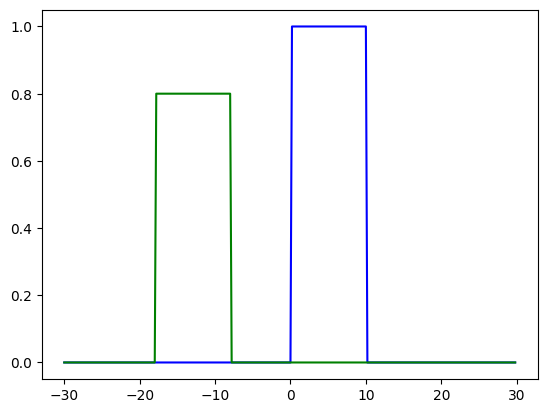

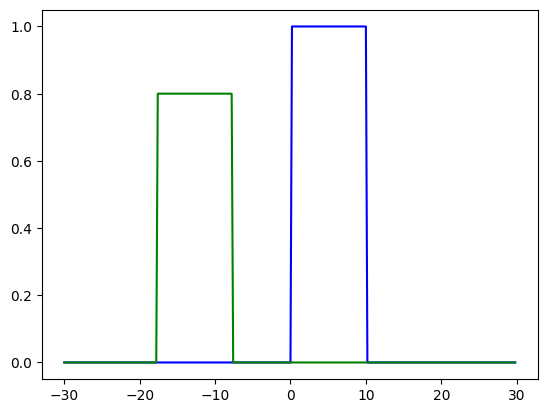

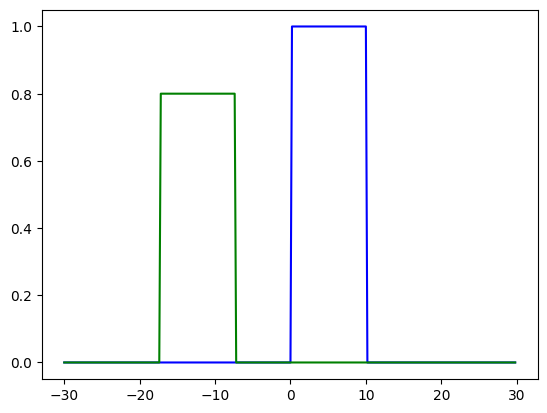

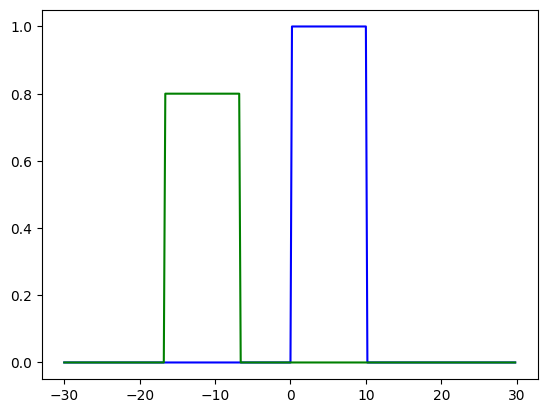

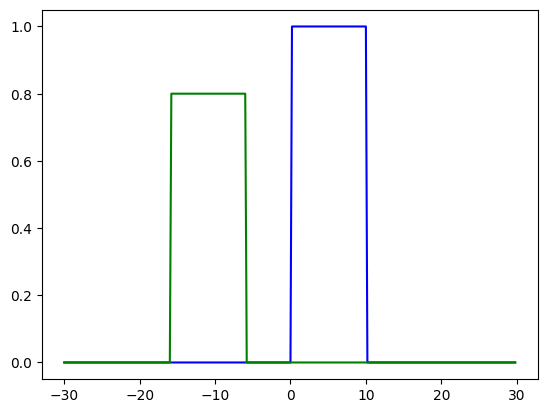

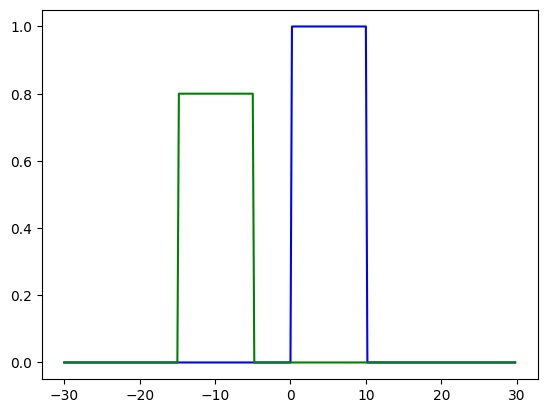

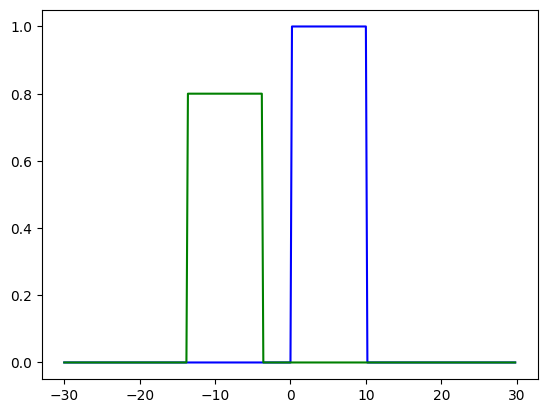

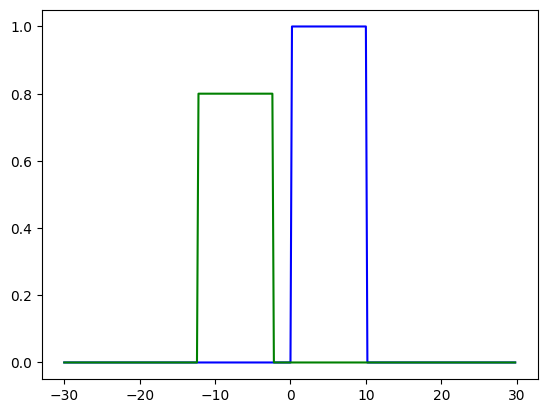

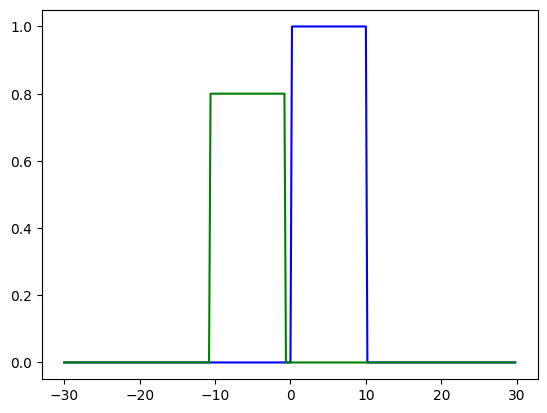

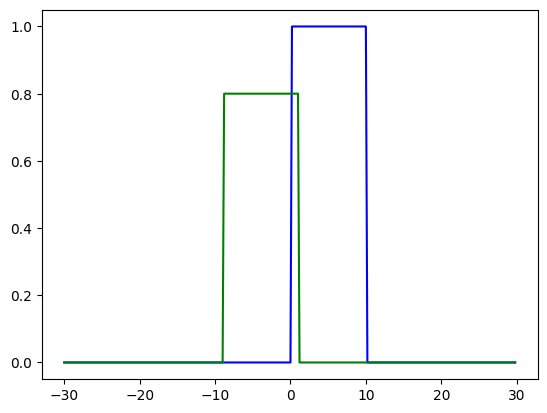

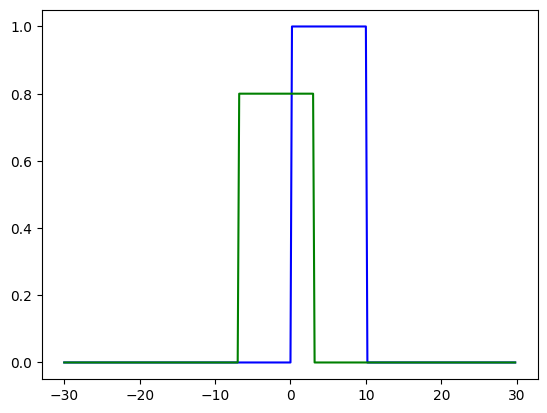

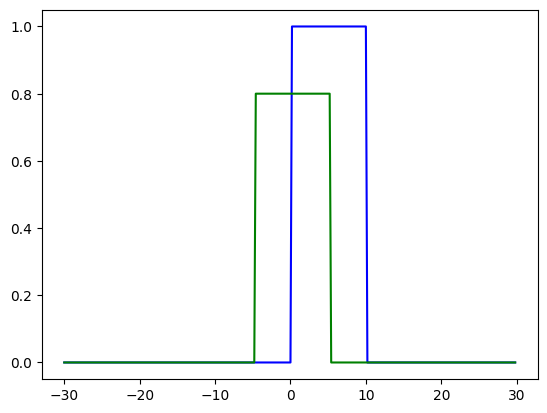

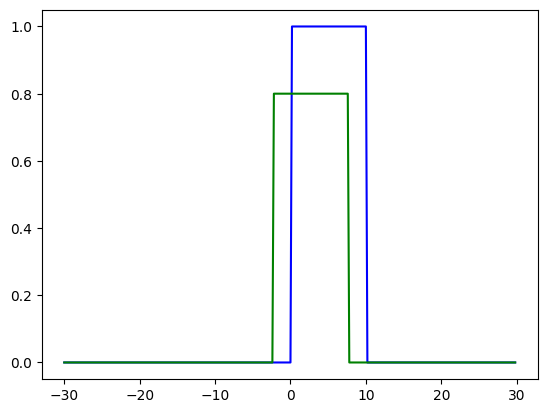

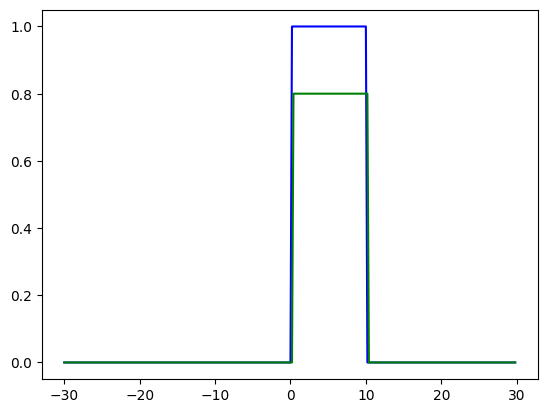

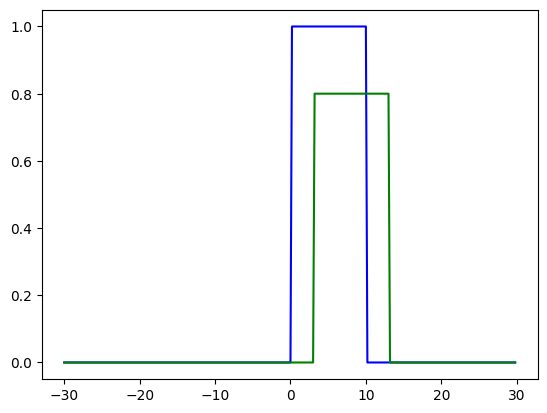

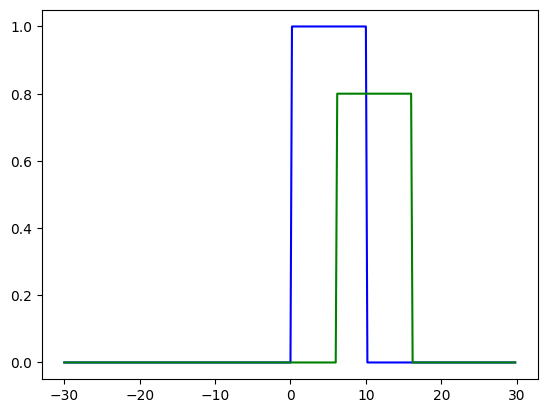

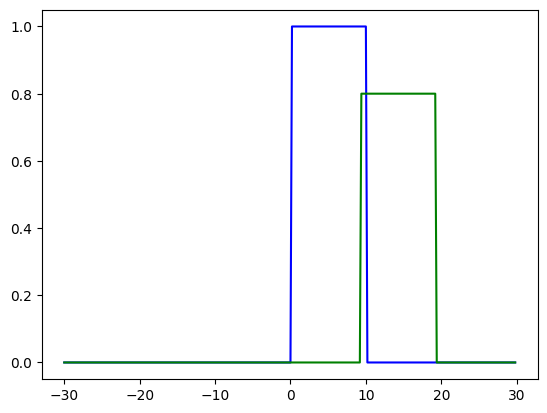

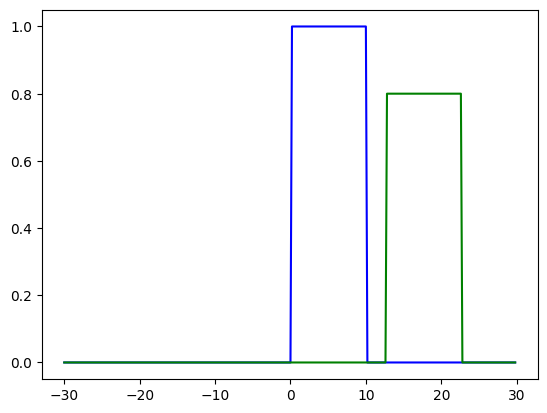

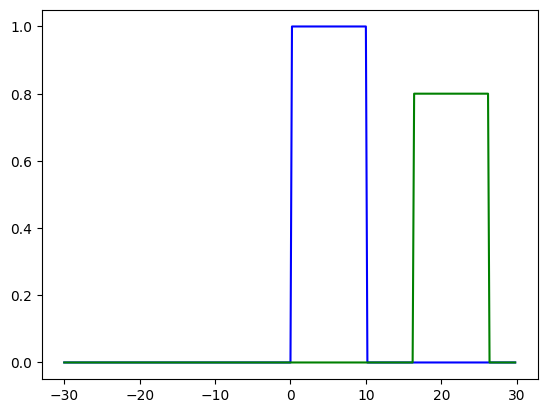

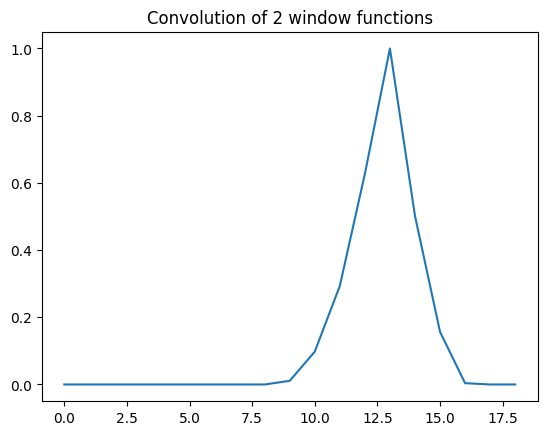

In [4]:
#and now let's move funct2 slowly on the x axis and calculate the convolution of funct1 with funct2:
#we will do this in N steps
N = 19
convs = np.zeros( N )

#go through the steps, calculate convolution and plot to see what happens at each step
for t in range( N ):
    
    # roll the function slowly over the x axis
    funct2 = np.roll( funct2, t )
    
    #identify max x where funct2 > 0:
    xlm    =  np.max( x[ funct2 >0 ] ) 
    
    #identify cross-section of 2 functs:
    cr_x   = np.where( (funct1 > 0) & (funct2>0 )  )
    cr_sec = x[ cr_x ]
   
    #if they do have an overlap calculate the convolution:
    if len(cr_sec) >1:
        x1 = np.min( cr_sec ) #lower limit of cross-section
        x2 = np.max( cr_sec ) #upper limit of cross-section
        
        #integral can be approximated by surface underneath:
        
        # if we are within the const function:
        if xlm <= m2 :
            #get base of parallelogram and multiply by height:
            prod1 = ( x2- m1 ) 
            prod2 = ( x2 - m1 ) * w 
            #get total integral
            convs[ t ] = prod1 * prod2
            
        #if our function has rolled away:
        if xlm > m2 :
            prod1 = ( m2- x1 ) 
            prod2 = ( m2- x1 ) * w
            convs[ t ] =  prod1 * prod2
            
        
    else:
        #if no overlap:
        convs[ t ] = 0
        
    #plot to see each step:
    plt.plot( x, funct1, 'b')
    plt.plot(x, funct2, 'g')
    plt.show()
    
#at the very end plot the final convolution:
plt.plot(convs / np.max( convs ))
dm = plt.title('Convolution of 2 window functions')

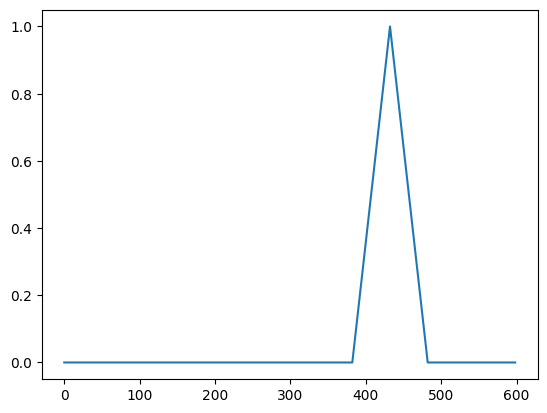

In [5]:
#of course, numpy is there to help:
np_convs = np.convolve(funct1, funct2, mode='full')
dm = plt.plot( np_convs / np.max( np_convs ) )

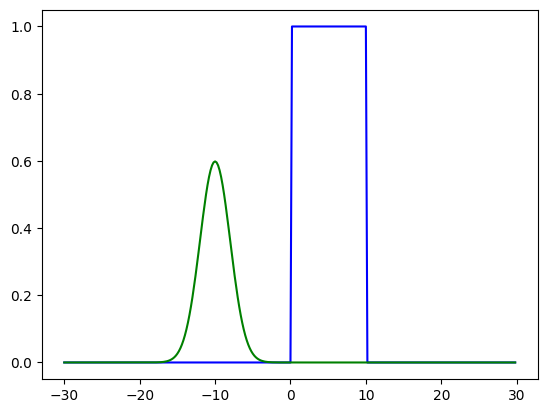

In [6]:
# convolution of a gaussian with a window function:
mu, sig = -10, 2
funct3 = 3 * ( ( 1 / (np.sqrt(2.0 * np.pi) * sig) ) * np.exp(-np.power((x - mu) / sig, 2.0) / 2) )

#let's visualize the 2 funct first: 
plt.plot( x, funct1, 'b')
dm = plt.plot( x, funct3, 'g')

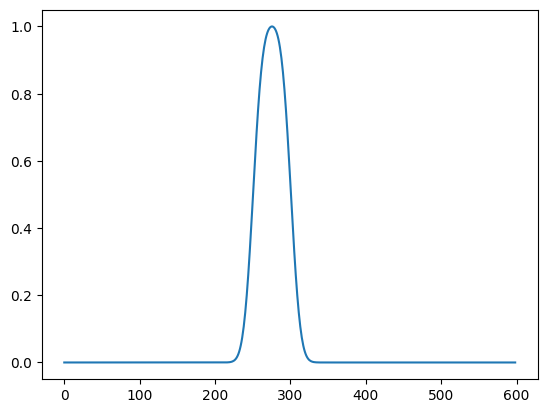

In [7]:
np_convs_2 = np.convolve(funct1, funct3, mode='full')

dm = plt.plot( np_convs_2/ np.max( np_convs_2 ))

### for astronomy, kernels are often symmetric
- Used for smoothing
- Can be calculated fast with Fourier Transforms

### you should avoid np.convolve and switch to astropy: https://docs.astropy.org/en/stable/convolution/

In [8]:
from astropy.convolution import convolve, convolve_fft


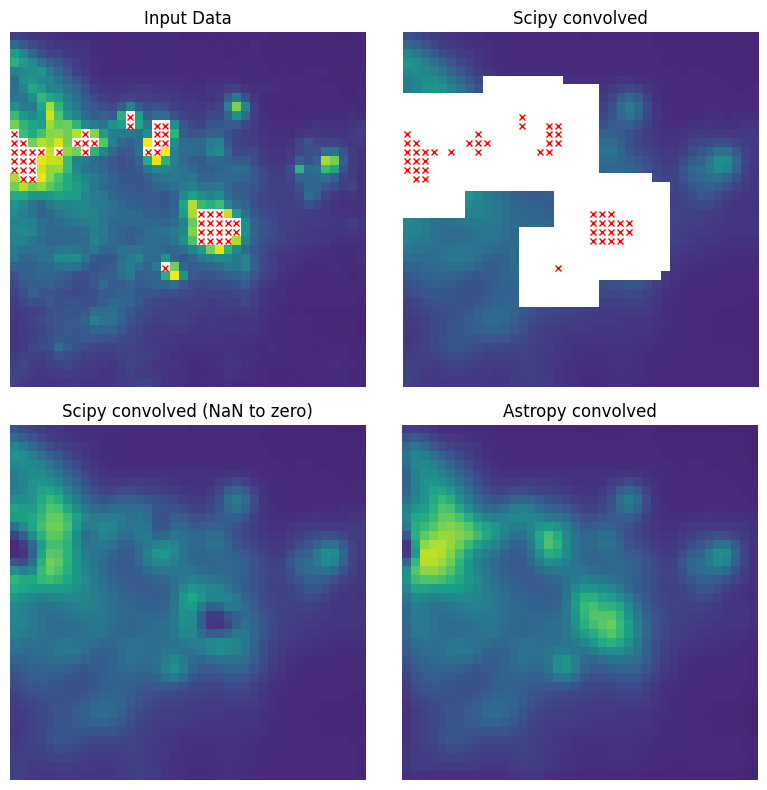

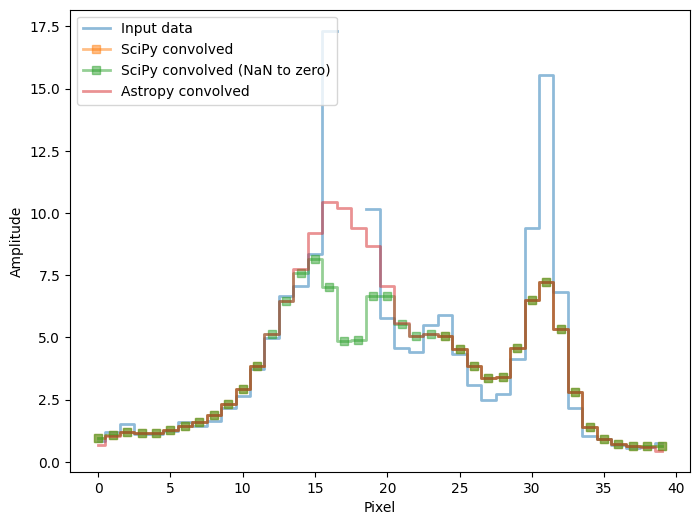

In [9]:
#from astropy 

from astropy.convolution import Gaussian2DKernel
from astropy.utils.data import get_pkg_data_filename
from scipy.ndimage import convolve as scipy_convolve

# Load the data from data.astropy.org
filename = get_pkg_data_filename('galactic_center/gc_msx_e.fits')
hdu = fits.open(filename)[0]

# Scale the file to have reasonable numbers
# (this is mostly so that colorbars do not have too many digits)
# Also, we crop it so you can see individual pixels
img = hdu.data[50:90, 60:100] * 1e5

# This example is intended to demonstrate how astropy.convolve and
# scipy.convolve handle missing data, so we start by setting the
# brightest pixels to NaN to simulate a "saturated" data set
img[img > 20] = np.nan

# We also create a copy of the data and set those NaNs to zero.  We will
# use this for the scipy convolution
img_zerod = img.copy()
img_zerod[np.isnan(img)] = 0

# We smooth with a Gaussian kernel with x_stddev=1 (and y_stddev=1)
# It is a 9x9 array
kernel = Gaussian2DKernel(x_stddev=1)

# Convolution: scipy's direct convolution mode spreads out NaNs (see
# panel 2 below)
scipy_conv = scipy_convolve(img, kernel)

# scipy's direct convolution mode run on the 'zero'd' image will not
# have NaNs, but will have some very low value zones where the NaNs were
# (see panel 3 below)
scipy_conv_zerod = scipy_convolve(img_zerod, kernel)

# astropy's convolution replaces the NaN pixels with a kernel-weighted
# interpolation from their neighbors
astropy_conv = convolve(img, kernel)

# Now we do a bunch of plots.  In the first two plots, the originally masked
# values are marked with red X's
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95,
                    wspace=0.3, hspace=0.3)
ax = ax.flatten()
for axis in ax:
    axis.axis('off')

im = ax[0].imshow(img, vmin=-2.0, vmax=20.0, origin='lower',
                  interpolation='nearest', cmap='viridis')
y, x = np.where(np.isnan(img))
ax[0].plot(x, y, 'rx', markersize=4)
ax[0].set_title("Input Data")
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])

im = ax[1].imshow(scipy_conv, vmin=-2.0, vmax=20.0, origin='lower',
                  interpolation='nearest', cmap='viridis')
ax[1].plot(x, y, 'rx', markersize=4)
ax[1].set_title("Scipy convolved")
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])

im = ax[2].imshow(scipy_conv_zerod, vmin=-2.0, vmax=20.0, origin='lower',
                  interpolation='nearest', cmap='viridis')
ax[2].set_title("Scipy convolved (NaN to zero)")
ax[2].set_xticklabels([])
ax[2].set_yticklabels([])

im = ax[3].imshow(astropy_conv, vmin=-2.0, vmax=20.0, origin='lower',
                  interpolation='nearest', cmap='viridis')
ax[3].set_title("Astropy convolved")
ax[3].set_xticklabels([])
ax[3].set_yticklabels([])

plt.tight_layout()

# we make a second plot of the amplitudes vs offset position to more
# clearly illustrate the value differences
plt.figure(2, figsize=(8, 6)).clf()
plt.plot(img[:, 25], label='Input data', drawstyle='steps-mid', linewidth=2,
         alpha=0.5)
plt.plot(scipy_conv[:, 25], label='SciPy convolved', drawstyle='steps-mid',
         linewidth=2, alpha=0.5, marker='s')
plt.plot(scipy_conv_zerod[:, 25], label='SciPy convolved (NaN to zero)',
         drawstyle='steps-mid', linewidth=2, alpha=0.5, marker='s')
plt.plot(astropy_conv[:, 25], label='Astropy convolved', drawstyle='steps-mid',
         linewidth=2, alpha=0.5)
plt.xlabel("Pixel")
plt.ylabel("Amplitude")
plt.legend(loc='best')
plt.show()

In [10]:
astro_conv = convolve_fft( funct1, funct3 )

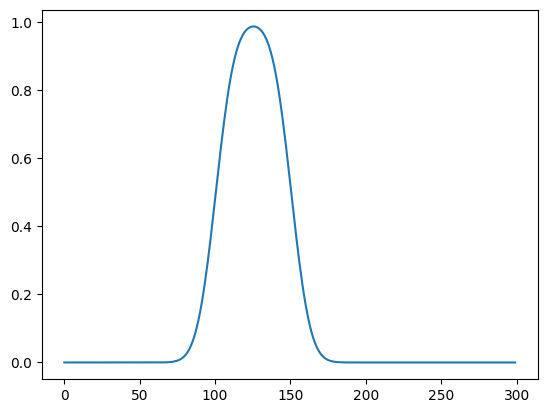

In [11]:
plt.plot( astro_conv )

#### OK, so why is it important? 

## Point Spread Functions (PSFs)


- Consider a perfect, point-like light source, far away
- Atmosphere has cells of air w/ differing temperatures
- Cells refract light, also move
- High-speed images show stellar point source bouncing around

<img src="Eps_aql_movie_not_2000.gif" width=300>

- From [central limit theorem](https://en.wikipedia.org/wiki/Central_limit_theorem) $\rightarrow$ point source follows Gaussian distribution 



- The PSF:
    - Airy diffraction pattern (see later)
    - Telescope aberrations ([astigmatism](https://en.wikipedia.org/wiki/Astigmatism_(optical_systems)), [coma](https://en.wikipedia.org/wiki/Coma_(optics)), etc.)
    - all these effects produce PSF
    - Convolve "reality" image with PSF $\rightarrow$ observed data


In [12]:
# psfdemo.py 
import radprof as rp
import gaussian as g

#plt.ion()

data, hdr = fits.getdata('SPITZER_I4_15891712_0692_0000_4_bcd.fits', \
                         header=True)

# 1D Gaussian
x = np.arange(-10., 10.005, 0.01)
plt.plot(x, g.gaussian(x))
z = np.array([2., 2, 3])
# use an array [3] as a single parameter vector
plt.plot(x, g.gaussian(x, *z))
plt.show()

a = np.indices([100, 100]) - 50
np.sum(g.gaussian(a, 3, 3))

# 2D Gaussian
plt.clf()
np.sum(g.gaussian(a, np.array([1, 2]), np.array([2, 3])))
plt.imshow(g.gaussian(a, [3, 5], [7, 3]))
plt.show()


plt.imshow(g.gaussian(a, param=[3, 2, 7, 3]))
plt.show()
# PSF

#

# single Spitzer frame, note central peak, incomplete ring, bg noise
im1 = plt.imshow( data[0] , cmap = 'gray',origin='lower')
plt.colorbar( im1 )
plt.show()


AttributeError: module 'numpy' has no attribute 'product'

C:\Users\Alex\AppData\Local\Temp\ipykernel_7320\3846247081.py:7: RuntimeWarning: invalid value encountered in log
  im2 = plt.imshow( np.log(d2) , cmap = 'gray')


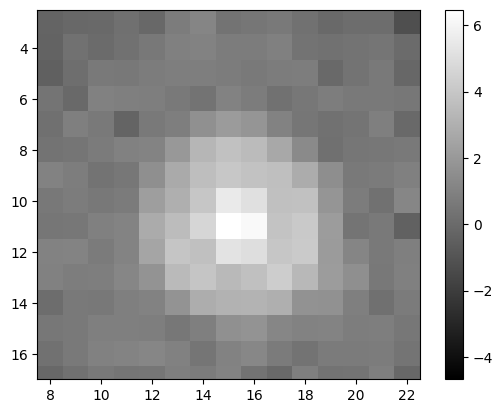

In [ ]:

# drag colormap to show brightest features and then dimmer ring
# view -> graph horiz, vert

# log scale and stretch to see outlying signal

d2 = data.mean(axis=0)
im2 = plt.imshow( np.log(d2) , cmap = 'gray')
plt.xlim( 7.5, 22.5 )
plt.ylim( 17, 2.5 )
plt.colorbar( im2 )
plt.show()


C:\Users\Alex\AppData\Local\Temp\ipykernel_7320\1758272291.py:2: RuntimeWarning: invalid value encountered in log
  im3 = plt.imshow(np.log(d2), cmap = 'gray' )


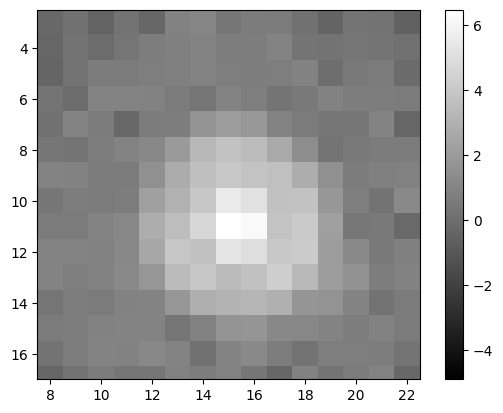

In [ ]:

d2 = np.median(data, axis=0)
im3 = plt.imshow(np.log(d2), cmap = 'gray' )
plt.xlim( 7.5, 22.5 )
plt.ylim( 17, 2.5 )
plt.colorbar( im3 )
plt.show()


### Airy diffraction pattern 
- # Fraunhoffer diffraction pattern follows a Bessel function found by Airy:

- For a perfect lens, perfect focus, perfect conditions we get the perfect Airy pattern
    
    <img src="Airy-pattern.png" width=300> (Airy pattern)
    
    
<img src="Airy_vs_gaus.png" width=300> (Airy pattern vs Gaussian distr.)
    
- $\sin\theta \sim 1.22 \frac{\lambda}{d} \rightarrow \theta \sim 1.22 \frac{\lambda}{d} $, with $\theta$ the location of first min; $\lambda$ the obs wav; $d$ the apperture
- IRL conditions though, you will not see this perfect pattern but rather an extended disk 


In [ ]:
import gaussian as g

# 1D Gaussian
x = np.arange(-10., 10.005, 0.01)
a = np.indices([100, 100]) - 50
# turn it into 2D Gaussian
np.sum(g.gaussian(a, np.array([1, 2]), np.array([2, 3])))
dm = plt.imshow(g.gaussian(a, [3, 5], [7, 3]))


AttributeError: module 'numpy' has no attribute 'product'

In [ ]:
dm = plt.imshow(g.gaussian(a, param=[3, 2, 7, 3]))

AttributeError: module 'numpy' has no attribute 'product'

In [ ]:
#or, to make things easier, astropy has its own function for making an Airy disk:
from astropy.convolution import AiryDisk2DKernel
airydisk_2D_kernel = AiryDisk2DKernel(10)
plt.imshow(airydisk_2D_kernel, interpolation='none', origin='lower')


In [ ]:
#note that this is a *perfect* airy disk though: 
quickmn = np.median(airydisk_2D_kernel)
quicksg = np.std(airydisk_2D_kernel)
nsl = -0.2
nsu = 0.2

plt.imshow(airydisk_2D_kernel, interpolation='none', origin='lower',
          vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg )

#we will see in next class how to convolve this with your telescope PSF (great for going from 
#model/simulation to 'observation' simulations)

### In class assignment (50 min) : 

### We will continue with the ICA from Flat fields. Note that a number of fields are already filled in, and we will go through them together, and some parts you need to code yourself.

- A) Read in all 6 of the flat field frames into Python so that you have a 6-by-2100-by-2068 three-dimensional array, i.e. a data cube.



In [13]:
fdir = r'C:\Users\Alex\Desktop\AST5765\lectures_git\lectures_week8\flats\\'

ffiles = os.listdir(fdir)

# They will be an 6 by 2068 by 2100 3D array so make empty cube
fdata = np.zeros( (6, 2068, 2100))

# Append them all to the data cube
for i in range(len(ffiles)):
    fdata[i, :, :] = fits.getdata( fdir + ffiles[i]).data

# there are 11 bias and each is of dimension 2068 by 2100
fdata.shape

(6, 2068, 2100)

- B) First we want to check that none of the flats are somehow corrupted, non-standard, or otherwise unhelpful. Visually inspect each flat to confirm whether all of them look fairly similar. What you are looking for is not whether the stars match, nor that the overall average ADU levels match, but rather that the structure in the background is the same. You may need to stretch the display appropriately to see what's going on in the background.



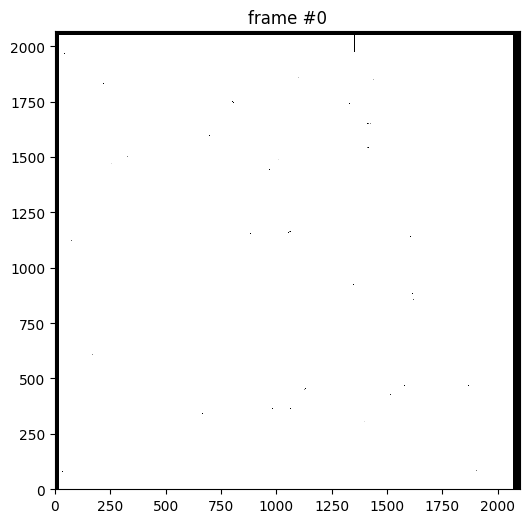

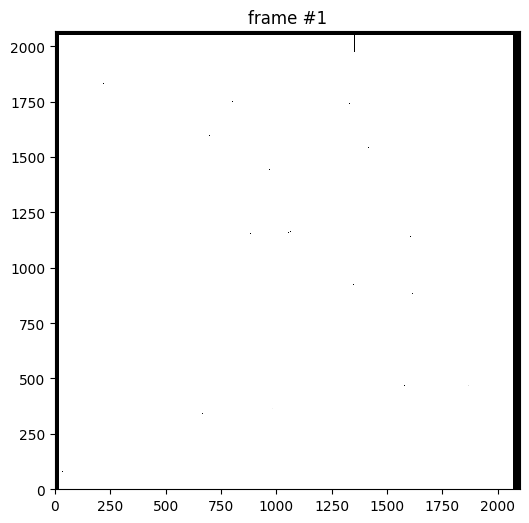

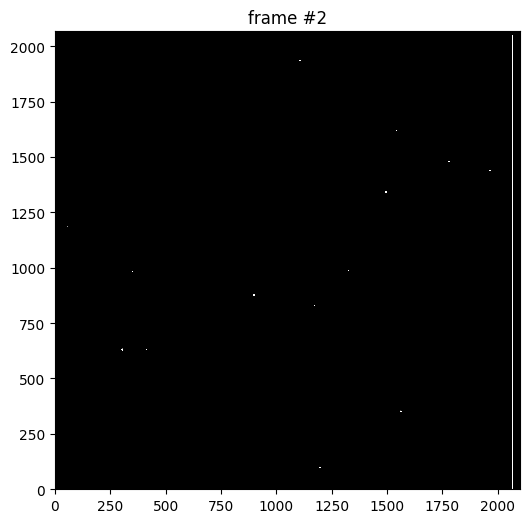

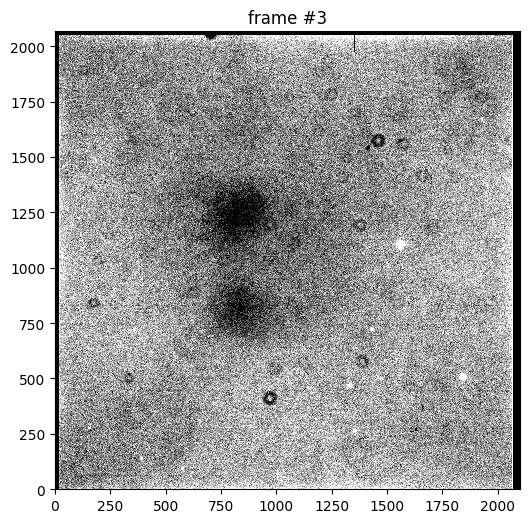

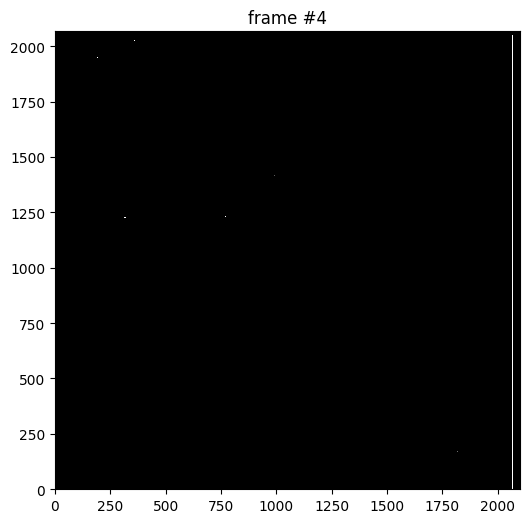

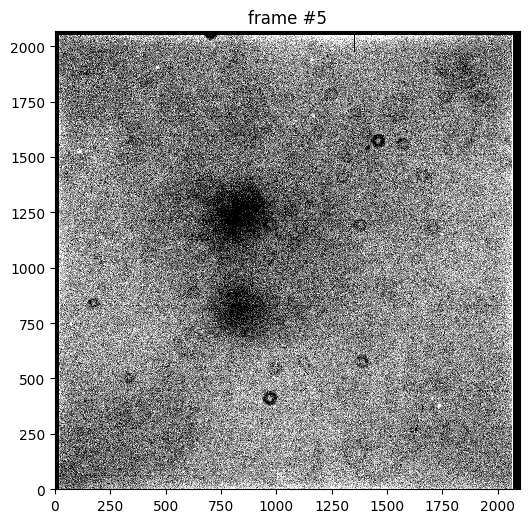

In [14]:
# Frame
for f in range(len(ffiles)):
    dts = fdata[i,:,:]
    quickmn = np.median(dts)
    quicksg = np.std(dts)
    nsl, nsu = -0.2, 0.2
    plt.figure( figsize = (6, 6) )
    plt.imshow(fdata[f, :, :], interpolation='none', origin='lower', 
           vmin=quickmn + nsl*quicksg, vmax=quickmn + nsu*quicksg, 
           cmap='gray')
    plt.title("frame #"+str(f))
    plt.show()

- C) Note that each raw flat-field frame includes not only light from the uniformally-illuminated sky but also the bias level. Therefore, subtract the master bias from each of the 6 slices of the data cube.


In [15]:
mbloc = r'C:\Users\Alex\Desktop\AST5765\lectures_git\lectures_week8\biases\master_bias.fits'
mb    = fits.getdata(mbloc)

fminb = np.zeros( (6, 2068, 2100))
for i in range(len(ffiles)):
    fminb[i, :, :] = fdata[i, :, :] - mb

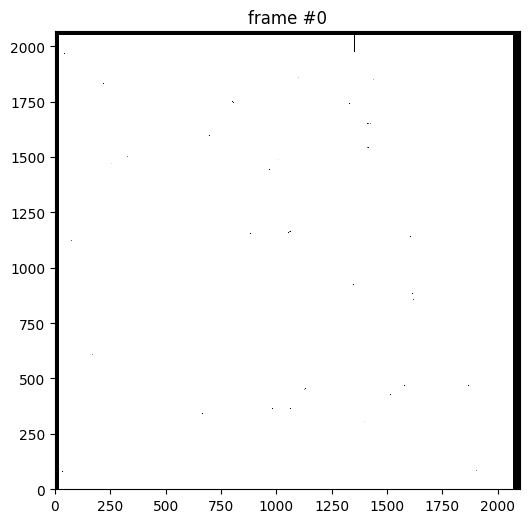

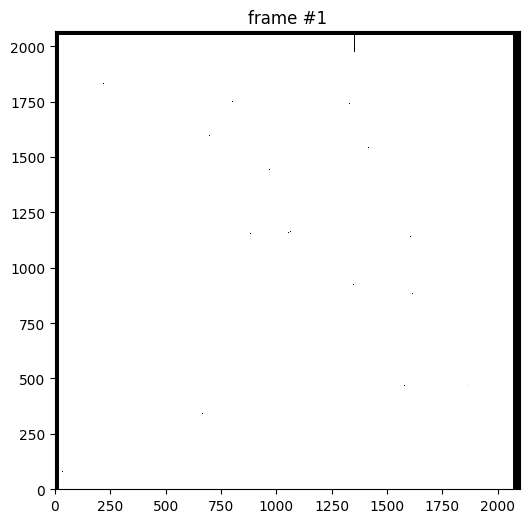

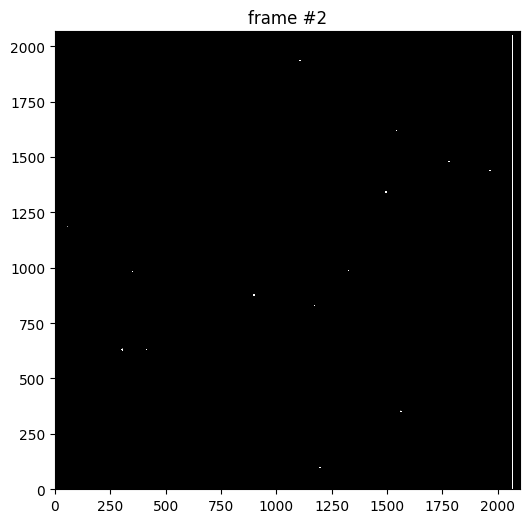

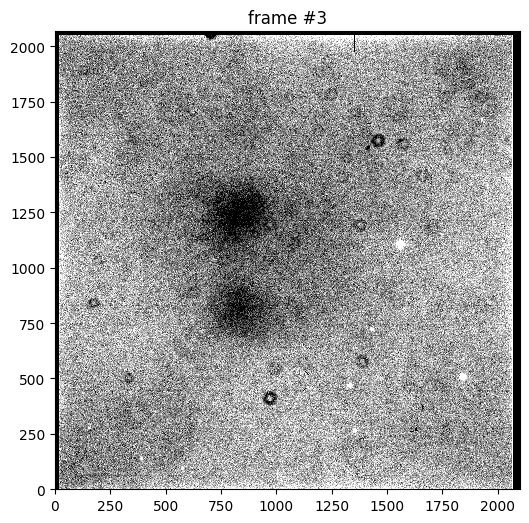

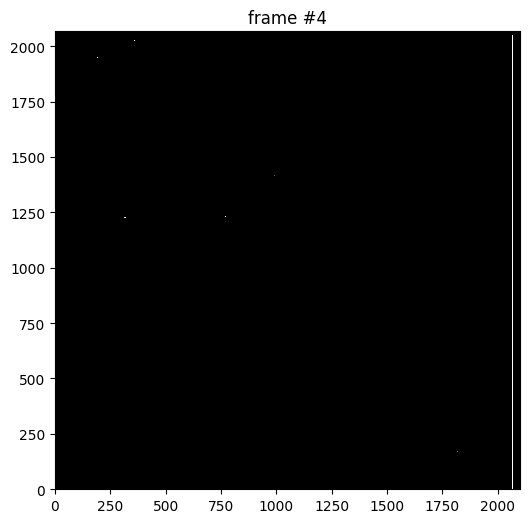

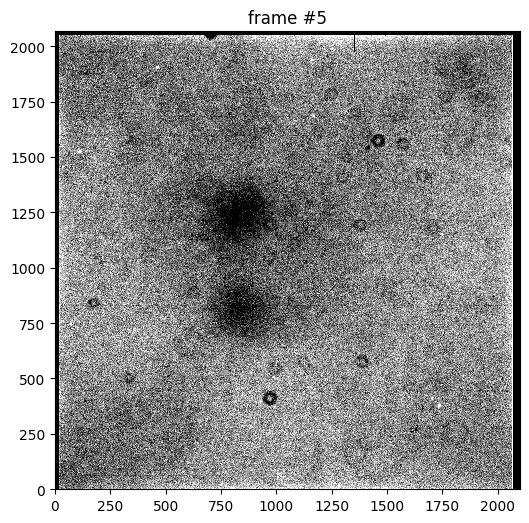

In [16]:
# Frame
for f in range(len(ffiles)):
    dts = fminb[i,:,:]
    quickmn = np.median(dts)
    quicksg = np.std(dts)
    nsl, nsu = -0.2, 0.2
    plt.figure( figsize = (6, 6) )
    plt.imshow(fminb[f, :, :], interpolation='none', origin='lower', 
           vmin=quickmn + nsl*quicksg, vmax=quickmn + nsu*quicksg, 
           cmap='gray')
    plt.title("frame #"+str(f))
    plt.show()

- D) Create a histogram of all the pixels in each of the 6 bias-subtracted flats from Part C. (Use a bin width of 1 unit.) Note that there will be a few pixels with very high counts that might make the main peak of the histogram very skinny. That is OK, such pixels won't be a problem. Just zoom in to the part of the histogram that has the bulk of the pixels and make note of the shape. Note that the histograms should all have more-or-less the same shape. The shape need not look Gaussian -- in fact generally flat-field histograms won't, although these ones happen to be close. Also note that the modes of all the histograms don't have to match either.



In [17]:
def getbinbounds(bw, arraymin, arraymax):
    intmin = np.floor(arraymin)
    intmax = np.ceil(arraymax)
    howmanybins = (intmax - intmin) / bw
    howmanybins = round(howmanybins)
    usethesebins = np.linspace(intmin, intmax, howmanybins+1)
    return usethesebins


In [18]:
binwid = 1.0

for i in range(len(ffiles)):
    


SyntaxError: incomplete input (4007378288.py, line 4)


- E)  Find the mode of each of the 6 histograms. 

- F)  If you zoom in you may notice that the peak of a histogram is sufficiently ratty that the specific bin that's technically the mode doesn't match where your eye might draw a smooth curve around the peak. So let's get a better estimate. For each of the flats, use curvefit or numpy's polyfit routine to fit a parabola (i.e. a quadratic function) to the part of the histogram near the peak, and use the resulting coefficients to get a better assessment of where the histogram's peak really is. (Recall that if $y = ax^2 + bx+c $, then the extremum of y occurs at $x=-\frac{b}{2a}$. How many counts off is the mode from Part E from this estimate?



In [ ]:
# Finding the mode, similar to what I've done,
# FInding ht eindex of the max value of th histogram and indexing this value
# IN the flats

# TO fit, polyfit, polyval, or polynomial.Polynomial
# Doing a parabolic fit because it is Gaussian

- G) Normalize each of the 6 flats by its individual adjusted mode based on your answers in Part F.



In [19]:
xmax = ([16539, 9360, 18656, 13524, 13613, 9138])

normal = np.zeros( (6, 2068, 2100))
for i in range(len(ffiles)):
    normal[i, :, :] = (fminb[i, :, :] /  xmax[i])

print(np.mean(normal[5, :, :]))

1.4298301620049885


- H) Now do the median-combine of all the individual normalized, bias-subtracted flats and thus create a master flat. Display this master flat (with an appropriate stretch so that you can see what's going on), and save the plot.



In [ ]:
flat_med = np.median(normal, axis = 0)


- I)  Write out the master flat into a FITS file.

- J) What is the median of the master flat? How close is it to a value of 1? (Hint: It should be very close.)



In [21]:
fits.writeto('master_flat.fits', flat_med)

- K ) Read in all 3 of the target frames into Python so that you have a 3-by-2100-by-2068 three-dimensional array, i.e. a data cube.



- L) Clean each of the target frames by first subtracting the master bias and then dividing by the master flat. Display each of the raw images as well as the cleaned-up images (with an appropriate stretch so that you can see what's going on in the background), and save the plots. 
    - [Note: Your master flat may have pixels that are equal to exactly 0. This will cause problems then when you try to divide by them! You should mask your data to remove those points. Then there should be no more zero values in your master flat.] 

#### In principle, you would now be ready to go to the next stage of the photometry process --- finding the number of ADUs contributed to each of those three cleaned images by the astronomical source of interest.